# Market Risk and Stress Testing in Python

---

#### Overview:

This notebook focuses on market risk and stress testing in Python, with a clear emphasis on measuring and communicating downside risk rather than predicting markets, generating alpha, optimising portfolios, or building trading strategies. Market risk is defined as the potential for losses arising from movements in market prices across asset classes such as equities, interest rates, foreign exchange, commodities, and cryptocurrencies. Rather than forecasting price direction, the goal of market risk management is to understand the distribution of potential losses, assess how large losses can be under normal conditions, and evaluate portfolio exposure during periods of market stress. The course presents a practical workflow that starts from raw market data and culminates in a concise, decision-ready risk report, prioritising clarity, interpretability, and realism throughout.

A central concept covered is Value at Risk (VaR), which measures the loss level that is not expected to be exceeded with a specified confidence level over a given time horizon. While VaR is widely used, it has important limitations: it does not represent a worst-case loss and provides no information about the severity of losses beyond the threshold. Since VaR focuses on loss frequency rather than tail severity, it can significantly underestimate risk during market crises. For this reason, VaR is always complemented by stress testing, which examines the impact of extreme but plausible scenarios and shifts the focus from probability to resilience. This notebook also highlights that all risk models rely on assumptions and historical data, making them decision-support tools rather than precise forecasts, and it discusses sources of model risk and limitations. Finally, it outlines natural extensions of the framework, including portfolio-level risk analysis, Monte Carlo simulation, expected shortfall, and model validation, with the aim of providing a solid practical foundation for market risk analysis in Python rather than a comprehensive treatment.

### Objective:

The ultimate aim of this notebook is to give users an understanding of how to communicate the idea of risk and reporting it in a table like the one shown below:

| Metric                         | Value          |
|--------------------------------|----------------|
| Historical VaR 95%              | -16528.402646  |
| Parametric VaR 95% (Normal)     | -17257.104545  |
| Tail Loss (worst 1%) avg        | -44167.342105  |
| Worst Drawdown                  | -337172.495090 |
| Stress PnL (-5%)                | -50000.000000  |
| Worst 10 days avg PnL           | -66001.409257  |

From the above table:
- Historical and parametric VaR at the 95% level estimate losses on a typical bad day and are shown side by side for comparison.
- Tail loss (worst 1% average) highlights that losses beyond VaR are often far larger, demonstrating why VaR alone is insufficient.
- Worst drawdown captures peak-to-trough losses over time, reflecting prolonged stress that impacts capital, leverage, and investor behaviour.
- A stress scenario translates a sharp market move (e.g. −5%) directly into P&L, emphasising resilience rather than probability.
- Worst 10-day average P&L provides a model-free sanity check on tail severity by averaging the most extreme historical losses.



#### Step 1: Preparing and Loading the Market Data

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import yfinance as yf
from scipy.stats import norm

In [4]:
df = yf.download("SPY", start="2010-01-01")['Close']
df = df.squeeze()
returns = df.pct_change().dropna()

df.tail(5)

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_29694/3148649698.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("SPY", start="2010-01-01")['Close']
[*********************100%***********************]  1 of 1 completed


Date
2026-02-04    686.190002
2026-02-05    677.619995
2026-02-06    690.619995
2026-02-09    693.950012
2026-02-10    696.119995
Name: SPY, dtype: float64

In [5]:
returns.tail(5)

Date
2026-02-04   -0.004844
2026-02-05   -0.012489
2026-02-06    0.019185
2026-02-09    0.004822
2026-02-10    0.003127
Name: SPY, dtype: float64

#### Step 2: Return Diagnostics and Distribution

In [6]:
summary = pd.DataFrame({
  'mean_daily_return': [returns.mean()],
  'vol_daily': [returns.std()],
  'min_daily': [returns.min()],
  'max_daily': [returns.max()],
  'n_observations': [returns.shape[0]]
})

summary

,mean_daily_return,vol_daily,min_daily,max_daily,n_observations
0,0.000578,0.010822,-0.109424,0.105019,4050


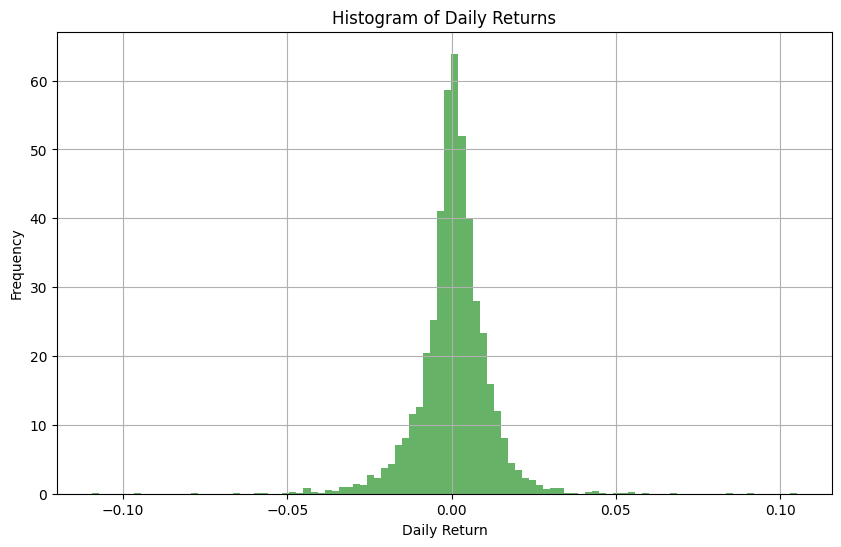

In [7]:
plt.figure(figsize=(10,6))
returns.hist(bins=100, density=True, alpha=0.6, color='g')
plt.title('Histogram of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

#### Step 3: VaR (Historical, Parametric)

Value at Risk (VaR) is defined as the loss threshold that is not expected to be exceeded with a specified confidence level over a given time horizon. VaR is computed as an empirical quantile of the return distribution, and it focuses on quantifying potential losses under normal market conditions using two complementary approaches. 

- In the historical approach, VaR is computed directly as an empirical quantile of the observed return distribution, making minimal assumptions about the underlying data. This method relies entirely on past market behaviour and captures features such as skewness and fat tails that may be present in historical returns.
- In the parametric approach, VaR assumes a specific distribution for returns, most commonly a normal distribution, and estimates risk using the mean and volatility of the return series. While this approach is more model-driven and computationally efficient, it depends on the validity of its distributional assumptions and can underestimate risk when returns exhibit non-normal behaviour. By computing both historical and parametric VaR side by side, we gain insight into how model assumptions influence risk estimates and can better assess the robustness of our downside risk measurement.

**Historical VaR**

In [9]:
CL_95 = 0.95
CL_99 = 0.99

var_historical_95 = np.percentile(returns, 100 * (1 - CL_95))
var_historical_99 = np.percentile(returns, 100 * (1 - CL_99))

var_df = pd.DataFrame({
  'VaR Type': ['Historical', 'Historical'],
  'Confidence Level': [f'{int(CL_95*100)}%', f'{int(CL_99*100)}%'],
  'VaR (return)': [var_historical_95, var_historical_99]
})
var_df

,VaR Type,Confidence Level,VaR (return)
0,Historical,95%,-0.016523
1,Historical,99%,-0.030620


Remarks of Historical VaR (Limitations):

---

- First, it is entirely backward-looking, assuming that the future will resemble the past. If market conditions, volatility regimes, or correlations change, historical VaR may severely underestimate or misrepresent current risk. This makes it particularly fragile around structural breaks, such as financial crises or policy regime shifts.
- Second, historical VaR is highly sensitive to the chosen data window. Using too short a history can lead to unstable estimates driven by noise, while using too long a history may dilute recent market dynamics that are more relevant for current risk. The choice of lookback period is therefore subjective and can materially affect results.
- Third, historical VaR provides no information about tail severity beyond the VaR threshold. Once the quantile is breached, it tells us nothing about how large losses can become, which is exactly when risk management matters most. This limitation is critical during periods of stress, when losses tend to cluster and grow much larger than historical VaR suggests.
- Finally, historical VaR implicitly assumes that historical observations are independent and identically distributed, ignoring volatility clustering and time-varying risk. As a result, it may fail to react quickly to rising market risk, making it less effective as a forward-looking risk signal. For these reasons, historical VaR is best used alongside complementary measures such as stress testing and expected shortfall.

**Parametric VaR**

In [10]:
mu = returns.mean()
sigma = returns.std()

var_parametric_95 = norm.ppf(1 - CL_95, loc=mu, scale=sigma)
var_parametric_99 = norm.ppf(1 - CL_99, loc=mu, scale=sigma)

var_df_parametric = pd.DataFrame({
  'VaR Type': ['Parametric', 'Parametric'],
  'Confidence Level': [f'{int(CL_95*100)}%', f'{int(CL_99*100)}%'],
  'VaR (return)': [var_parametric_95, var_parametric_99]
})
var_df_parametric

,VaR Type,Confidence Level,VaR (return)
0,Parametric,95%,-0.017222
1,Parametric,99%,-0.024597


In [12]:
comparison_df = pd.DataFrame({
  'Historical VaR': [var_historical_95, var_historical_99],
  'Parametric VaR': [var_parametric_95, var_parametric_99]
}, index=[f'{int(CL_95*100)}% CL', f'{int(CL_99*100)}% CL'])
comparison_df

,Historical VaR,Parametric VaR
95% CL,-0.016523,-0.017222
99% CL,-0.030620,-0.024597


#### Step 4: VaR Backtesting

Value at Risk estimation is only the first step in risk analysis; the next step is to assess whether the model behaves as intended when compared against realized returns, which is the purpose of VaR backtesting. Backtesting is conceptually straightforward: once a VaR threshold is fixed, realized daily returns are examined and each instance where losses exceed the VaR level is recorded as an exception. The backtesting table summarizes the performance of a historical 95% VaR model with a constant threshold over the full sample.

In [13]:
var_threshold = var_historical_95
exceptions = returns < var_threshold
exception_rate = exceptions.mean()

output = pd.DataFrame({
  'VaR Model': ['Historical VaR 95% CL'],
  'VaR Threshold (return)': [var_threshold],
  'Exception Rate': [exception_rate],
  'Number of Exceptions': [exceptions.sum()],
  'Total Observations': [returns.shape[0]]
})
output

,VaR Model,VaR Threshold (return),Exception Rate,Number of Exceptions,Total Observations
0,Historical VaR 95% CL,-0.016523,0.050123,203,4050


- The VaR threshold, expressed in return space, is approximately −1.65%, meaning any daily return worse than this level counts as a breach. 
- For a 95% VaR model, the expected exception rate is 5%, and the observed exception rate of approximately 5.01% is very close to this benchmark.
- Out of 4,050 observations, 203 exceptions are recorded, indicating that the results are based on a substantial sample rather than statistical noise. This suggests that, in terms of frequency, the model performs largely as intended. 

Remarks:

---

However, passing a frequency-based backtest does not imply the model is complete or sufficient, as VaR backtesting only evaluates how often breaches occur, not how severe the losses are or how they cluster over time. A model can meet expected exception rates while still underestimating extreme tail losses. In practice, VaR backtesting serves as a monitoring tool rather than a guarantee of safety, with persistent deviations potentially signaling model breakdowns or regime changes. For this reason, VaR is always complemented by tail risk measures and stress testing, which explicitly address losses beyond the VaR threshold.

#### Step 5: Tail Risk

Up to this point, the analysis has focused on Value at Risk (VaR), which defines a loss threshold at a chosen confidence level but deliberately ignores what happens beyond that cutoff. To address this limitation, the focus now shifts to tail risk, which examines the behavior of returns in the extreme left tail of the distribution and asks how severe losses can become once markets move sharply against us.

In this framework, the tail is defined as the worst 1% of daily returns, corresponding to a 1% tail quantile.

In [14]:
tail_q = 0.01
tail_cutoff = returns.quantile(tail_q)
tail_losses = returns[returns <= tail_cutoff]

tail_stats = pd.DataFrame({
  'Tail Quantile': [tail_q],
  'Cutoff Return': [tail_cutoff],
  'Mean Tail Loss': [tail_losses.mean()],
  'Median Tail Loss': [tail_losses.median()],
  'Min Tail Loss': [tail_losses.min()],
  'Number of Tail Losses': [tail_losses.shape[0]]
})

tail_stats

,Tail Quantile,Cutoff Return,Mean Tail Loss,Median Tail Loss,Min Tail Loss,Number of Tail Losses
0,0.01,-0.03062,-0.044167,-0.037968,-0.109424,41


Returns worse than the tail cutoff—approximately −3.07% based on historical estimates—are classified as tail events. Within this subset, the average loss is around −4.42%, demonstrating that losses conditional on entering the tail are materially larger than the VaR threshold itself. The most extreme observation in the sample is a single-day loss of approximately −10.94%, highlighting the magnitude of downside risk that VaR entirely fails to capture. With 41 tail observations out of roughly 4,000 trading days, the empirical results are consistent with the chosen tail definition. This comparison underscores a fundamental weakness of VaR: while it indicates where losses begin to become concerning, it provides no insight into how large those losses can be.

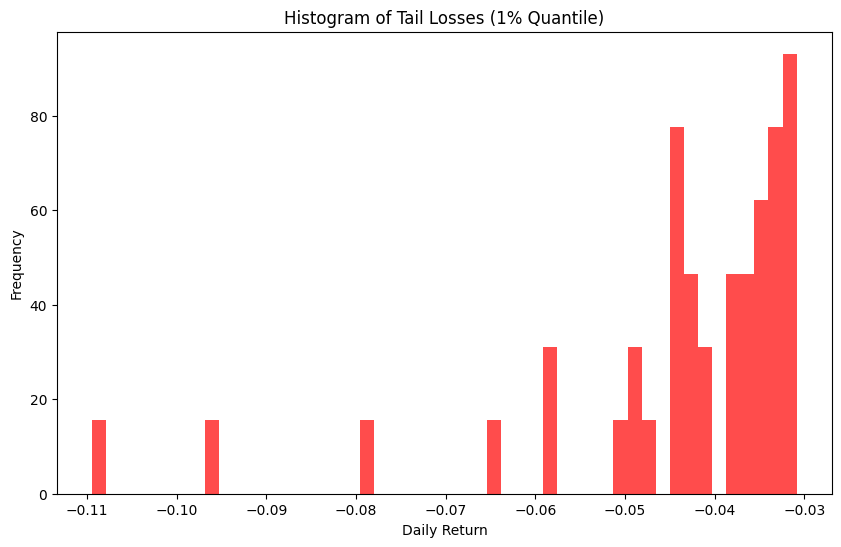

In [15]:
# Plotting the tail losses distribution
plt.figure(figsize=(10,6))
plt.hist(tail_losses, bins=50, density=True, alpha=0.7, color='r')
plt.title('Histogram of Tail Losses (1% Quantile)')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

The dispersion observed within the tail—illustrated by the histogram of tail returns—shows that even extreme losses are highly variable, ranging from moderately severe to catastrophic. Importantly, this analysis focuses on loss severity rather than timing. In practice, tail risk measures complement VaR by providing critical insight into potential capital impacts during extreme market conditions, particularly for portfolios with leverage, nonlinear payoffs, or crisis-driven correlations. Having examined tail risk empirically, the analysis naturally progresses to stress testing, where losses are evaluated under hypothetical market shocks rather than relying solely on historical data.

#### Step 6: Stress Testing

Stress testing complements tail risk analysis by taking a forward-looking approach to downside risk, assessing how a portfolio would perform under specific adverse market scenarios. Initial hypothetical stress tests impose predefined shocks, such as −3%, −5%, or −10%, to estimate portfolio losses in a simple, linear framework for clarity and transparency. More complex portfolios, including commodities, futures, options, and leveraged strategies, require advanced stress models to account for nonlinearities, convexity, and path dependence.

In [16]:
port_folio_value = 1_000_000
shocks = [-0.03, -0.05, -0.10]
stress_table = pd.DataFrame({
  'shock_return': shocks,
  'stress_pnl': [port_folio_value * shock for shock in shocks]
})
stress_table

,shock_return,stress_pnl
0,-0.03,-30000.0
1,-0.05,-50000.0
2,-0.10,-100000.0


In [24]:
N = 10
worst_days = returns.nsmallest(N)
hist_stress = pd.DataFrame({
  'Date': worst_days.index,
  'Daily Return': worst_days.values,
  'pnl': worst_days.values * port_folio_value
})
hist_stress

,Date,Daily Return,pnl
0,2020-03-16,-0.109424,-109423.906735
1,2020-03-12,-0.095677,-95677.199078
2,2020-03-09,-0.078094,-78094.498535
3,2011-08-08,-0.065123,-65123.276877
4,2025-04-04,-0.058543,-58542.909993
5,2020-06-11,-0.057649,-57648.916499
6,2020-03-18,-0.050633,-50632.890548
7,2025-04-03,-0.049281,-49280.943991
8,2020-03-11,-0.048749,-48748.554212
9,2011-08-04,-0.046841,-46841.180242


Historical stress events, such as the 16 March 2020 COVID-19 sell-off (−10.9% return, −109,000 loss), demonstrate that extreme losses have occurred in practice. Comparing hypothetical and historical stresses provides a comprehensive view of potential downside exposure. Overall, stress testing complements VaR and tail risk by offering intuitive, scenario-based insights for decision-making. The analysis then proceeds to drawdowns, which capture cumulative losses over time rather than single-day shocks.

#### Step 7: Drawdowns

In [21]:
cum = (1 + returns).cumprod()
dd = cum / cum.cummax() - 1

dd_stats = pd.DataFrame({
  'Max Drawdown': [dd.min()],
  'Max Drawdown pnl': [dd.min() * port_folio_value]
})
dd_stats

,Max Drawdown,Max Drawdown pnl
0,-0.337173,-337172.706844


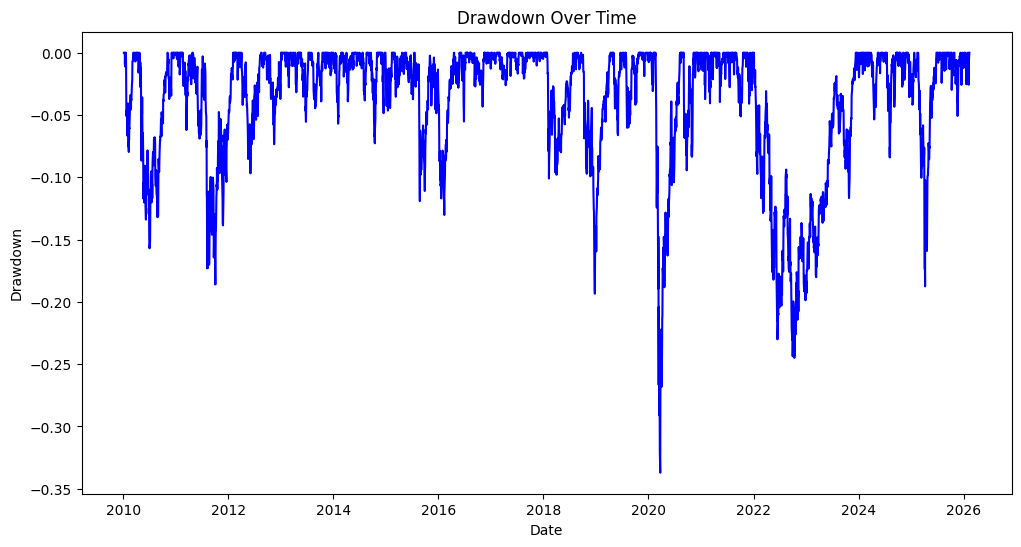

In [22]:
# Plt the drawdown over time
plt.figure(figsize=(12,6))
plt.plot(dd.index, dd.values, color='blue')
plt.title('Drawdown Over Time')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.show()

#### Step 8: Assembling the Market Risk Report

In [27]:
report = pd.DataFrame({
  'Metric': [
    f"Historical VaR {int(var_historical_95 * 100)}%",
    f"Parametric VaR {int(var_parametric_95 * 100)}%",
    f"Tail Loss (worst {int(tail_q*100)}%) avg",
    'Max Drawdown',
    "Stress PnL (-5%)",
    f"Worst {N} Days avg PnL"
  ],
  'Value': [
    var_historical_95 * port_folio_value,
    var_parametric_95 * port_folio_value,
    tail_losses.mean() * port_folio_value,
    dd.min() * port_folio_value,
    -0.05 * port_folio_value,
    hist_stress['pnl'].mean() if len(hist_stress) > 0 else 0
  ]
})
report

,Metric,Value
0,Historical VaR -1%,-16522.513347
1,Parametric VaR -1%,-17222.071020
2,Tail Loss (worst 1%) avg,-44167.332111
3,Max Drawdown,-337172.706844
4,Stress PnL (-5%),-50000.000000
5,Worst 10 Days avg PnL,-66001.427671
